# 인하대 후문 · 합성 카드데이터로 연습하는 문제 진단

> **모든 카드 결제건수·금액·고객 속성은 인위적으로 생성한 값입니다. 실제 매출·고객·상권 문제를 나타내지 않습니다.**
> 공개 샘플의 17개 필드 구조만 참고했습니다. 마스킹된 샘플로 실제 분포를 복원하거나 추정하지 않았습니다.

**목표:** 데이터가 들어왔을 때 어떻게 검증·집계·결합하고 문제 후보를 검토할지 실행 예제로 확인합니다.

1. 현재 데이터의 범위 확인 → 2. 합성 카드 생성 → 3. 월별 추이와 학사일정 결합
4. 같은 동의 업종 구성 비교 → 5. 시간대·연령 예시 → 6. 인구·버스 시점 연결 → 7. 문제 진단의 한계

공개 명세 출처: [데이터안심구역](https://dsz.kdata.or.kr/svc/data/search.do)에서 ‘지역별매출’ 검색 → 미리보기.
명세는 대화에서 확인한 17개 필드를 반영합니다. 실제 코드값의 정의·금액 단위·읍면동 구분은 미확정입니다.

### 실데이터와 합성값의 경계

| 내용 | 상태 | 분석 단위 |
|---|---|---|
| 2026.06 점포와 사용자 경계 | 실제 확보 자료 | 후문 534개 / 관련 행정동 전체 |
| 주민등록인구 | 실제 확보 자료 | 2026.06·08 행정동 전체 |
| 버스 승하차 | 실제 확보 자료 | 2026.06 정류장별; 고유 방문자 아님 |
| 인하대 학사일정 | 공식 웹 수집 | 2024~2026; 정규학기 구간은 분석용 추론 |
| 카드자료 | **100% 합성** | 2024.01~2026.06 행정동 단위라는 예제 가정 |
| 비교지역 | **완전히 가상** | `DEMO000001`, 실제 지명·비교상권 아님 |

**실행:** 프로젝트 `.venv` 커널로 위에서부터 실행합니다. 네트워크 요청·새 패키지 설치는 없습니다.
출력은 `outputs/synthetic_card_demo/`에만 저장합니다. 기존 실데이터 결과는 덮어쓰지 않습니다.


In [1]:
from pathlib import Path
import hashlib
import json
import math
import os
import tempfile
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir())/'inha-demo-mpl'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT/'data/inha_boundary.geojson').exists():
    raise FileNotFoundError('노트북을 Commercial district analysis 프로젝트 폴더에서 실행하세요.')
OUT = ROOT/'outputs/synthetic_card_demo'
OUT.mkdir(parents=True, exist_ok=True)
for font in ['AppleGothic','Malgun Gothic','NanumGothic']:
    if any(f.name == font for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = font
        break
plt.rcParams.update({'axes.unicode_minus':False, 'figure.dpi':110})
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
SEED = 20260915
CARD_STATUS = 'SYNTHETIC — 실제 카드매출 아님'
TITLE = '합성 카드 예시 · 실제 매출 아님'

def chart_done(fig, filename):
    fig.tight_layout()
    fig.savefig(OUT/filename, dpi=150, bbox_inches='tight')
    plt.show()

def export_demo(frame, name):
    frame.assign(card_data_status=CARD_STATUS).to_csv(OUT/name, index=False, encoding='utf-8-sig')


## 1. 현재 데이터 로딩과 공간 단위 확인

후문 경계 점포와 **관련 행정동 전체 점포를 별도로** 가져옵니다.
카드의 `UMD_CD`가 행정동 10자리라는 예제 가정으로만 연결합니다. 실제 자료가 법정동이면 연결표부터 바꿔야 합니다.


In [2]:
meta = json.loads((ROOT/'data/raw/district_stores.json').read_text())
district_stores = pd.DataFrame(meta['rows'])
boundary_stores = pd.read_csv(ROOT/'outputs/inha/stores.csv', dtype={'bizesId':str,'adongCd':str})
boundary = json.loads((ROOT/'data/inha_boundary.geojson').read_text())
boundary_summary = json.loads((ROOT/'outputs/inha/summary.json').read_text())
assert hashlib.sha256((ROOT/'data/inha_boundary.geojson').read_bytes()).hexdigest() == boundary_summary['boundary_sha256'], '경계 변경 후 analyze_inha_boundary.py를 먼저 실행하세요.'
assert meta['complete'] and meta['total'] == len(district_stores)
assert district_stores.bizesId.is_unique and boundary_stores.bizesId.is_unique
assert set(boundary_stores.bizesId) <= set(district_stores.bizesId)
assert boundary_stores.adongCd.nunique() == 1, '여러 동이면 동별 분석 설계가 필요합니다.'
TARGET_ADONG = boundary_stores.adongCd.iloc[0]
TARGET_DONG = TARGET_ADONG+'00'
TARGET_NAME = boundary_stores.adongNm.iloc[0]
REFERENCE_DONG = 'DEMO000001'
dong_stores = district_stores[district_stores.adongCd.astype(str).eq(TARGET_ADONG)].copy()
calendar = pd.read_csv(ROOT/'outputs/inha/academic_monthly_features.csv', dtype={'month':str})
population = pd.read_csv(ROOT/'outputs/population_dong_summary.csv', dtype={'month':str,'dong_code':str})
months = pd.period_range('2024-01','2026-06',freq='M').strftime('%Y%m').tolist()
calendar = calendar[calendar.month.isin(months)].copy()
assert calendar.month.is_unique and set(calendar.month) == set(months)
display(pd.DataFrame([
    ['후문 사용자 경계',len(boundary_stores),'실제 점포; 카드 공간 단위로 사용하지 않음'],
    [TARGET_NAME+' 전체',len(dong_stores),'실제 점포; 합성 카드와 비교할 공통 공간'],
    ['미추홀구 전체',len(district_stores),'실제 점포; 업종 비교 기준'],
],columns=['범위','점포 수','용도']))
print('예제 카드 UMD_CD 가정:',TARGET_DONG,'=',TARGET_NAME,'행정동 전체')


,범위,점포 수,용도
0,후문 사용자 경계,534,실제 점포; 카드 공간 단위로 사용하지 않음
1,용현1.4동 전체,1349,실제 점포; 합성 카드와 비교할 공통 공간
2,미추홀구 전체,18885,실제 점포; 업종 비교 기준


예제 카드 UMD_CD 가정: 2817754000 = 용현1.4동 행정동 전체


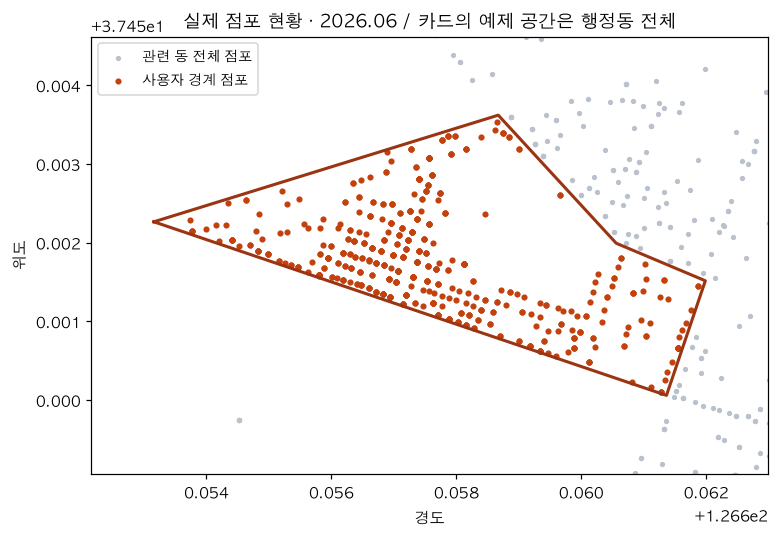

In [3]:
fig, ax = plt.subplots(figsize=(9,5))
ring = np.asarray(boundary['geometry']['coordinates'][0])
ax.scatter(dong_stores.lon,dong_stores.lat,s=6,c='#b8c1cc',label='관련 동 전체 점포')
ax.scatter(boundary_stores.lon,boundary_stores.lat,s=9,c='#c2410c',label='사용자 경계 점포')
ax.plot(ring[:,0],ring[:,1],c='#9a3412',lw=2)
ax.set(xlim=(ring[:,0].min()-.001,ring[:,0].max()+.001),
       ylim=(ring[:,1].min()-.001,ring[:,1].max()+.001),xlabel='경도',ylabel='위도',
       title='실제 점포 현황 · 2026.06 / 카드의 예제 공간은 행정동 전체')
ax.set_aspect(1/math.cos(math.radians(ring[:,1].mean())))
ax.legend(fontsize=9)
chart_done(fig,'real_boundary_context.png')


## 2. 샘플 구조와 예제 코드표

17개 원래 필드명을 유지합니다. `STD_YM`은 월이며 **날짜·요일·가맹점ID·고유 고객ID는 없습니다.**
한 행은 월·지역·업종·고객 속성·시간대 등의 조합별 결제 집계입니다.

- 지역: 실제 행정동 코드를 예제 가정으로 사용하지만 그 행의 결제값은 합성입니다.
- 업종·고객·시간 코드: `D`로 시작하는 **가상 코드**. 공식 코드와 혼동하지 않습니다.
- 업종은 공공 상가 대분류 10개에 대응하는 가상 중분류를 하나씩 둡니다. 실제 신한 업종 매핑표가 아닙니다.
- `PHOLI_CLCD`의 D1/D2는 정의를 알 수 없는 공휴일 코드 대신 둔 **가상 유형 A/B**입니다. 평일·주말 분석으로 부르지 않습니다.
- 나이는 20~79세 6개 구간만 생성합니다. 미성년·80세 이상은 이 예제에서 제외합니다.
- 개인카드만 생성하며, 생애주기·소득은 D0(예제 미설정)로 고정합니다. 이 항목의 분포를 모사하지 않습니다.
- 결제금액은 예제에서 원 단위라고 가정합니다. 실제 단위 확인이 필요합니다.


In [4]:
dimensions = [
    'STD_YM','WIAR_SIDO_CD','SGNG_CD','UMD_CD','TOBU_BIDVS_CD','TOBU_MEDVS_CD',
    'PERS_CORP_CLCD','PHOLI_CLCD','TIZO_CLCD','SEX_CLCD','N10_UNIT_AGE_CLCD',
    'HSH_LFTM_PERD_CD','EST_INCM_SECT_CD','IFW_AREA_CD','IFW_DISTC_SECT_CD'
]
fields = dimensions+['PAYM_NOCA','PAYM_AMT']
industry_map = (district_stores[['indsLclsCd','indsLclsNm']].drop_duplicates()
                .sort_values('indsLclsCd').reset_index(drop=True))
industry_map['TOBU_BIDVS_CD'] = [f'D{i+1:02d}' for i in range(len(industry_map))]
industry_map['TOBU_MEDVS_CD'] = [f'D{i+1:03d}' for i in range(len(industry_map))]
industry_map['mapping_status'] = 'DEMO_ONLY — 공식 카드 업종 매핑 아님'
industry_map.to_csv(OUT/'demo_industry_codebook.csv',index=False,encoding='utf-8-sig')
age_codes = {f'D{i}':f'{i*10}~{i*10+9}세' for i in range(2,8)}
time_codes = {'D1':'00~10시','D2':'11~14시','D3':'15~17시','D4':'18~23시'}
origin_codes = {'DEMOLOCAL1':'가상 유입유형 A','DEMOREST01':'가상 유입유형 B','DEMOAWAY01':'가상 유입유형 C'}
codebook = dict(age=age_codes,time=time_codes,origin=origin_codes,
    sex={'D1':'가상 남성','D2':'가상 여성'},holiday={'D1':'가상 유형 A','D2':'가상 유형 B'},
    personal={'D1':'개인카드만 생성'},household={'D0':'예제 미설정'},income={'D0':'예제 미설정'},
    distance={'D1':'가상 거리구간 A','D2':'가상 거리구간 B','D3':'가상 거리구간 C'})
(OUT/'demo_attribute_codebook.json').write_text(json.dumps(codebook,ensure_ascii=False,indent=2))
schema = pd.DataFrame({'field':fields,'demo_type':['string']*15+['integer','integer']})
schema.to_csv(OUT/'sample_schema_17_fields.csv',index=False)
display(industry_map)
print('공개 샘플 필드 수:',len(fields),'| 가상 코드표를 실제 데이터에 적용하면 안 됩니다.')


,indsLclsCd,indsLclsNm,TOBU_BIDVS_CD,TOBU_MEDVS_CD,mapping_status
0,G2,소매,D01,D001,DEMO_ONLY — 공식 카드 업종 매핑 아님
1,I1,숙박,D02,D002,DEMO_ONLY — 공식 카드 업종 매핑 아님
2,I2,음식,D03,D003,DEMO_ONLY — 공식 카드 업종 매핑 아님
3,L1,부동산,D04,D004,DEMO_ONLY — 공식 카드 업종 매핑 아님
4,M1,과학·기술,D05,D005,DEMO_ONLY — 공식 카드 업종 매핑 아님
5,N1,시설관리·임대,D06,D006,DEMO_ONLY — 공식 카드 업종 매핑 아님
6,P1,교육,D07,D007,DEMO_ONLY — 공식 카드 업종 매핑 아님
7,Q1,보건의료,D08,D008,DEMO_ONLY — 공식 카드 업종 매핑 아님
8,R1,예술·스포츠,D09,D009,DEMO_ONLY — 공식 카드 업종 매핑 아님
9,S2,수리·개인,D10,D010,DEMO_ONLY — 공식 카드 업종 매핑 아님


공개 샘플 필드 수: 17 | 가상 코드표를 실제 데이터에 적용하면 안 됩니다.


## 3. 합성 카드 생성: 알려진 효과를 넣은 연습 시나리오

합성값은 공개 샘플의 통계적 분포를 추정한 결과가 아닙니다. 아래 조건을 **의도적으로** 넣습니다.

1. 합성 거래는 관련 동의 실제 업종별 점포 수를 기준 크기로 사용합니다. 따라서 이후 점포·소비 구성 비교는 독립적인 검증이 아닙니다.
2. 대학 학기 구간에는 가상 대상지역의 20·30대 음식·오락 거래가 증가하도록 설정합니다.
3. **2025년 9월부터 가상 대상지역의 음식 거래 기대건수를 15% 감소**시킵니다. 실제 사건·사업·쇠퇴를 뜻하지 않습니다.
4. 월별 완만한 성장·계절요인·무작위 변동을 함께 넣습니다. 감소가 모든 월의 총액 하락으로 그대로 나타나지는 않습니다.
5. 가상 비교지역은 실제 비교상권이 아닙니다. 차이가 보여도 정책 효과나 인과관계를 추정하지 않습니다.

생성 파라미터·시드·출처 파일 해시를 보존합니다. 동일 입력·환경이면 동일 데이터로 재실행됩니다.


In [5]:
def generate_card(seed):
    rng = np.random.default_rng(seed)
    base_counts = dong_stores.groupby('indsLclsCd').size()
    # 업종별 거래 빈도/건당금액은 모두 임의 가정. 실제 단가나 시장규모 아님.
    frequency = {'G2':100,'I1':12,'I2':100,'L1':2,'M1':8,'N1':8,'P1':10,'Q1':20,'R1':45,'S2':25}
    ticket = {'G2':18000,'I1':55000,'I2':12500,'L1':150000,'M1':65000,'N1':40000,'P1':80000,'Q1':30000,'R1':18000,'S2':25000}
    rows = []
    for month_index, cal in enumerate(calendar.itertuples()):
        seasonal = 1+.04*np.sin(2*np.pi*(int(cal.month[-2:])-1)/12)
        for region in [TARGET_DONG,REFERENCE_DONG]:
            for industry in industry_map.itertuples():
                group = industry.indsLclsCd
                monthly_base = base_counts[group]*frequency[group]*(cal.calendar_days/30)
                monthly_base *= (1+.002*month_index)*seasonal*rng.lognormal(0,.035)
                if region == REFERENCE_DONG:
                    monthly_base *= .85
                shock = .85 if region == TARGET_DONG and group == 'I2' and cal.month >= '202509' else 1.0
                for age_index,age in enumerate(age_codes):
                    age_weight = [.24,.22,.18,.16,.12,.08][age_index]
                    campus = (1+.5*cal.regular_term_share_inferred) if region == TARGET_DONG and group in ['I2','R1'] and age in ['D2','D3'] else 1.0
                    for time_index,time in enumerate(time_codes):
                        time_weight = ([.12,.32,.18,.38] if group in ['I2','R1'] else [.25,.3,.25,.2])[time_index]
                        for holiday_index,holiday in enumerate(['D1','D2']):
                            for sex in ['D1','D2']:
                                for origin_index,origin in enumerate(origin_codes):
                                    expectation = monthly_base*shock*campus*age_weight*time_weight*[.72,.28][holiday_index]*.5*[.5,.3,.2][origin_index]
                                    count = int(rng.poisson(expectation))
                                    amount = int(round(count*ticket[group]*rng.lognormal(0,.1))) if count else 0
                                    rows.append([cal.month,'2800000000','2817700000',region,
                                        industry.TOBU_BIDVS_CD,industry.TOBU_MEDVS_CD,'D1',holiday,time,sex,age,
                                        'D0','D0',origin,f'D{origin_index+1}',count,amount])
    return pd.DataFrame(rows,columns=fields)

card = generate_card(SEED)
assert list(card.columns) == fields and len(fields) == 17
assert not card.duplicated(dimensions).any()
assert card[fields].notna().all().all()
assert (card[['PAYM_NOCA','PAYM_AMT']] >= 0).all().all()
assert card.loc[card.PAYM_NOCA.eq(0),'PAYM_AMT'].eq(0).all()
assert card.STD_YM.str.fullmatch(r'\d{6}').all()
assert set(card.UMD_CD) == {TARGET_DONG,REFERENCE_DONG}
for col in ['PERS_CORP_CLCD','PHOLI_CLCD','TIZO_CLCD','SEX_CLCD','N10_UNIT_AGE_CLCD','HSH_LFTM_PERD_CD','EST_INCM_SECT_CD','IFW_DISTC_SECT_CD']:
    assert card[col].str.len().eq(2).all()
assert card.UMD_CD.str.len().le(10).all() and card.IFW_AREA_CD.str.len().le(10).all()
card.to_csv(OUT/'SYNTHETIC_shc_17_fields.csv',index=False,encoding='utf-8-sig')
print(CARD_STATUS, '|',len(card), '행 × 17필드')
display(card.head(5).assign(data_status='SYNTHETIC'))


SYNTHETIC — 실제 카드매출 아님 | 172800 행 × 17필드


,STD_YM,WIAR_SIDO_CD,SGNG_CD,UMD_CD,TOBU_BIDVS_CD,TOBU_MEDVS_CD,...,EST_INCM_SECT_CD,IFW_AREA_CD,IFW_DISTC_SECT_CD,PAYM_NOCA,PAYM_AMT,data_status
0,202401,2800000000,2817700000,2817754000,D01,D001,...,D0,DEMOLOCAL1,D1,304,5591070,SYNTHETIC
1,202401,2800000000,2817700000,2817754000,D01,D001,...,D0,DEMOREST01,D2,169,2802533,SYNTHETIC
2,202401,2800000000,2817700000,2817754000,D01,D001,...,D0,DEMOAWAY01,D3,133,2278468,SYNTHETIC
3,202401,2800000000,2817700000,2817754000,D01,D001,...,D0,DEMOLOCAL1,D1,273,5221652,SYNTHETIC
4,202401,2800000000,2817700000,2817754000,D01,D001,...,D0,DEMOREST01,D2,170,3428338,SYNTHETIC


## 4. 업종·학사일정 결합과 중복 집계 방지

코드표는 한 코드당 한 행, 학사일정은 한 달당 한 행이어야 합니다.
`many_to_one` 검증으로 한 카드행이 여러 행으로 늘어나는 조인을 막습니다. 결제건수·금액 합계가 보존되는지도 확인합니다.


In [6]:
assert industry_map.TOBU_MEDVS_CD.is_unique
enriched = card.merge(industry_map,on=['TOBU_BIDVS_CD','TOBU_MEDVS_CD'],how='left',validate='many_to_one')
enriched = enriched.merge(calendar,left_on='STD_YM',right_on='month',how='left',validate='many_to_one')
assert len(enriched) == len(card)
assert enriched.indsLclsNm.notna().all() and enriched.calendar_days.notna().all()
assert enriched.PAYM_AMT.sum() == card.PAYM_AMT.sum()
assert enriched.PAYM_NOCA.sum() == card.PAYM_NOCA.sum()

# 잘못된 학사일정 중복이 조용히 합계를 부풀리지 않는지 실제 실패 조건 점검.
try:
    card.head(1).merge(pd.concat([calendar,calendar.iloc[:1]]),left_on='STD_YM',right_on='month',validate='many_to_one')
except pd.errors.MergeError:
    print('PASS: 중복 달력행을 포함한 잘못된 결합 차단')
else:
    raise AssertionError('중복 키 검증 실패')
print('PASS: 결합 전후 행 수·결제 합계 보존')


PASS: 중복 달력행을 포함한 잘못된 결합 차단
PASS: 결합 전후 행 수·결제 합계 보존


## 5. 월별 흐름 + 실제 학사일정

월마다 날짜 수가 다르므로 월 합계와 **달력 1일당 평균 건수**를 함께 계산합니다.
이는 영업일당 건수가 아닙니다. 건당 금액은 `금액 합계 / 건수 합계`이며 고객당 지출이 아닙니다.
전년 동월 비교는 명시적으로 12개월 전 기준월에 연결하며, 최초 12개월은 결측으로 둡니다.


,STD_YM,PAYM_NOCA,PAYM_AMT,transactions_per_calendar_day,amount_per_transaction_assumed_krw,amount_yoy_pct,data_status
24,202601,89378,1511409989,"2,883.161","16,910.313",-3.016,SYNTHETIC
25,202602,81525,1364308323,"2,911.607","16,734.846",-5.315,SYNTHETIC
26,202603,108475,1773009555,"3,499.194","16,344.868",-2.280,SYNTHETIC
27,202604,103954,1694123445,"3,465.133","16,296.857",-3.672,SYNTHETIC
28,202605,106084,1726203729,"3,422.065","16,272.046",-5.848,SYNTHETIC
29,202606,96572,1570038943,"3,219.067","16,257.704",-8.890,SYNTHETIC


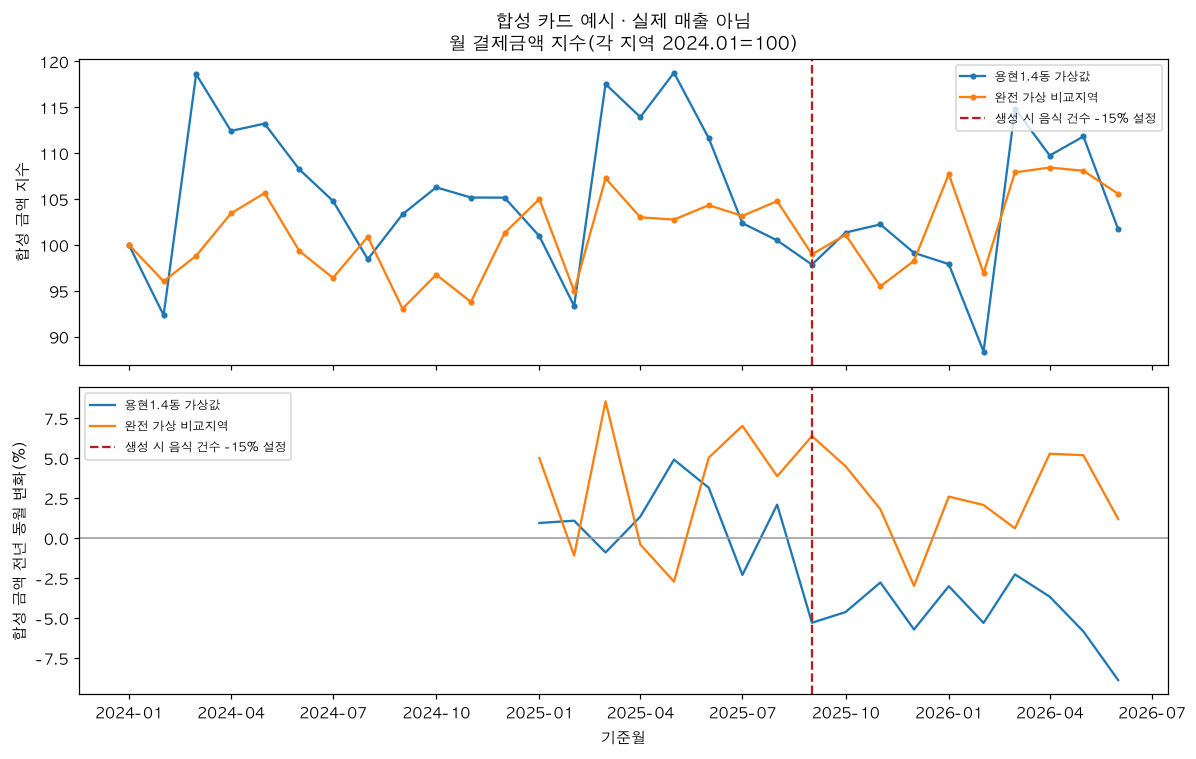

In [7]:
monthly = (enriched.groupby(['UMD_CD','STD_YM'],as_index=False)[['PAYM_NOCA','PAYM_AMT']].sum()
           .merge(calendar,left_on='STD_YM',right_on='month',validate='many_to_one'))
monthly['transactions_per_calendar_day'] = monthly.PAYM_NOCA/monthly.calendar_days
monthly['amount_per_transaction_assumed_krw'] = monthly.PAYM_AMT/monthly.PAYM_NOCA.replace(0,np.nan)
prior = monthly[['UMD_CD','STD_YM','PAYM_AMT','PAYM_NOCA']].copy()
prior['STD_YM'] = (pd.PeriodIndex(prior.STD_YM,freq='M')+12).strftime('%Y%m')
prior = prior.rename(columns={'PAYM_AMT':'prior_year_amount','PAYM_NOCA':'prior_year_count'})
monthly = monthly.merge(prior,on=['UMD_CD','STD_YM'],how='left',validate='one_to_one')
monthly['amount_yoy_pct'] = (monthly.PAYM_AMT/monthly.prior_year_amount-1)*100
monthly['count_yoy_pct'] = (monthly.PAYM_NOCA/monthly.prior_year_count-1)*100
monthly['region_label'] = monthly.UMD_CD.map({TARGET_DONG:TARGET_NAME+' 가상값',REFERENCE_DONG:'완전 가상 비교지역'})
assert monthly.prior_year_amount.notna().sum() == 36
export_demo(monthly,'SYNTHETIC_monthly_joined.csv')
display(monthly[monthly.UMD_CD.eq(TARGET_DONG)][['STD_YM','PAYM_NOCA','PAYM_AMT','transactions_per_calendar_day','amount_per_transaction_assumed_krw','amount_yoy_pct']].tail(6).assign(data_status='SYNTHETIC'))

fig, axes = plt.subplots(2,1,figsize=(11,7),sharex=True)
for region,g in monthly.groupby('UMD_CD'):
    g = g.sort_values('STD_YM')
    x = pd.to_datetime(g.STD_YM,format='%Y%m')
    axes[0].plot(x,g.PAYM_AMT/g.PAYM_AMT.iloc[0]*100,marker='.',label=g.region_label.iloc[0])
    axes[1].plot(x,g.amount_yoy_pct,label=g.region_label.iloc[0])
axes[0].set(title=TITLE+'\n월 결제금액 지수(각 지역 2024.01=100)',ylabel='합성 금액 지수')
axes[1].set(ylabel='합성 금액 전년 동월 변화(%)',xlabel='기준월')
axes[1].axhline(0,color='#999',lw=1)
for ax in axes:
    ax.axvline(pd.Timestamp('2025-09-01'),color='#b91c1c',ls='--',label='생성 시 음식 건수 -15% 설정')
    ax.legend(fontsize=8)
chart_done(fig,'SYNTHETIC_monthly_trend.png')


## 6. 학기 관련 패턴 예시: 월을 억지로 둘로 나누지 않기

음식 거래의 일평균 건수와 실제 학사일정에서 계산한 정규학기 구간 비중을 나란히 표시합니다.
정규학기 구간은 주말을 포함합니다. 6월·12월처럼 시험·보강·계절학기가 섞인 달은 그대로 유지합니다.

**주의:** 생성식에 학기 증가 효과를 넣었으므로 이 그림은 실제 대학 수요 효과의 발견이 아닙니다.


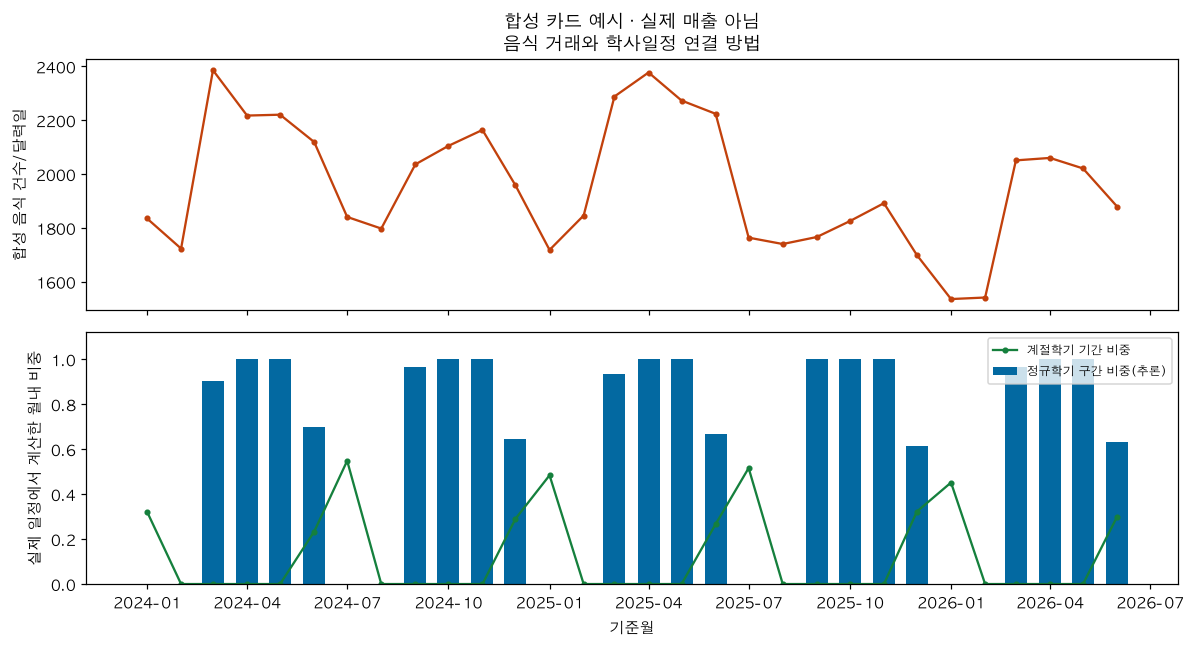

In [8]:
food_month = (enriched[enriched.indsLclsCd.eq('I2')].groupby(['UMD_CD','STD_YM'],as_index=False)[['PAYM_NOCA','PAYM_AMT']].sum()
              .merge(calendar,left_on='STD_YM',right_on='month',validate='many_to_one'))
food_month['count_per_calendar_day'] = food_month.PAYM_NOCA/food_month.calendar_days
target_food = food_month[food_month.UMD_CD.eq(TARGET_DONG)].sort_values('STD_YM')
fig, axes = plt.subplots(2,1,figsize=(11,6),sharex=True)
x = pd.to_datetime(target_food.STD_YM,format='%Y%m')
axes[0].plot(x,target_food.count_per_calendar_day,color='#c2410c',marker='.')
axes[0].set(title=TITLE+'\n음식 거래와 학사일정 연결 방법',ylabel='합성 음식 건수/달력일')
axes[1].bar(x,target_food.regular_term_share_inferred,width=20,color='#0369a1',label='정규학기 구간 비중(추론)')
axes[1].plot(x,target_food.seasonal_class_days/target_food.calendar_days,color='#15803d',marker='.',label='계절학기 기간 비중')
axes[1].set(ylabel='실제 일정에서 계산한 월내 비중',xlabel='기준월',ylim=(0,1.12))
axes[1].legend(fontsize=8)
chart_done(fig,'SYNTHETIC_calendar_alignment.png')
export_demo(food_month,'SYNTHETIC_food_calendar.csv')


## 7. 같은 동·같은 월의 업종 구성 비교

**2026.06 용현1.4동 전체 점포 구성비**와 **같은 동의 합성 카드금액 구성비**를 연결합니다.
후문 경계의 점포 수는 참고 열로만 표시합니다. 동 매출을 후문 점포 수로 나누거나 배분하지 않습니다.

구성비 차이는 서로 다른 측정량 간 차이입니다. 업종별 거래 빈도·객단가·카드 포착률·점포 규모가 다릅니다.
이 예제는 점포 수를 생성식에 사용하므로 더욱이 과밀·공백 검증으로 사용할 수 없습니다.


,indsLclsNm,real_dong_store_count,real_boundary_store_count_reference_only,real_dong_store_share_pct,synthetic_amount_share_pct,card_status
0,소매,279,68,20.680,33.430,SYNTHETIC
1,숙박,70,24,5.190,3.050,SYNTHETIC
2,음식,529,296,39.210,44.670,SYNTHETIC
3,부동산,58,30,4.300,1.110,SYNTHETIC
4,과학·기술,82,15,6.080,2.830,SYNTHETIC
5,시설관리·임대,50,9,3.710,1.110,SYNTHETIC
6,교육,29,3,2.150,1.620,SYNTHETIC
7,보건의료,9,0,0.670,0.340,SYNTHETIC
8,예술·스포츠,84,58,6.230,5.180,SYNTHETIC
9,수리·개인,159,31,11.790,6.650,SYNTHETIC


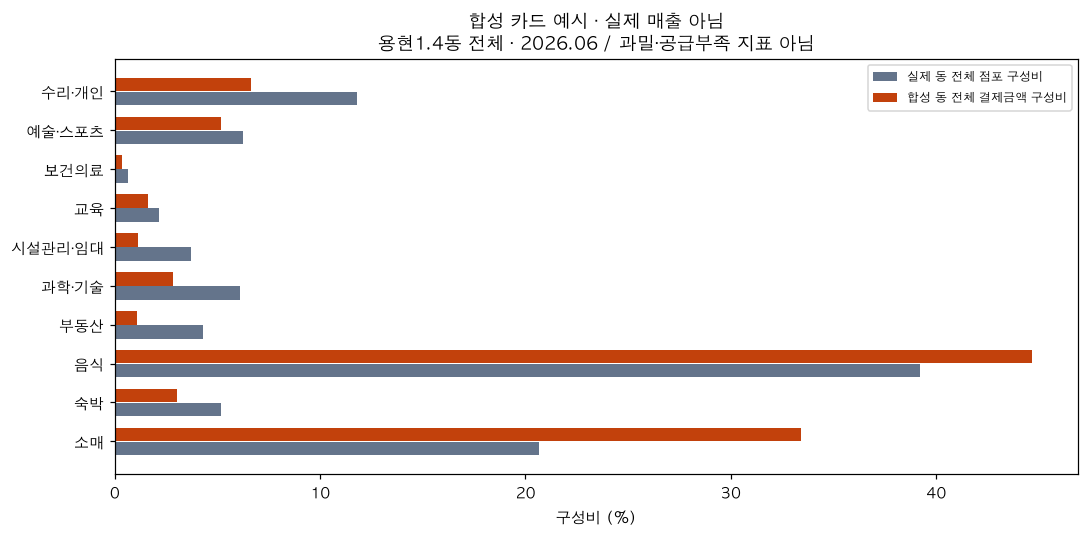

In [9]:
jun = enriched[enriched.UMD_CD.eq(TARGET_DONG)&enriched.STD_YM.eq('202606')]
mix = jun.groupby(['indsLclsCd','indsLclsNm'],as_index=False)[['PAYM_AMT','PAYM_NOCA']].sum()
mix['real_dong_store_count'] = mix.indsLclsCd.map(dong_stores.groupby('indsLclsCd').size()).fillna(0).astype(int)
mix['real_boundary_store_count_reference_only'] = mix.indsLclsCd.map(boundary_stores.groupby('indsLclsCd').size()).fillna(0).astype(int)
mix['real_dong_store_share_pct'] = mix.real_dong_store_count/len(dong_stores)*100
mix['synthetic_amount_share_pct'] = mix.PAYM_AMT/mix.PAYM_AMT.sum()*100
mix['share_difference_pp_not_supply_gap'] = mix.synthetic_amount_share_pct-mix.real_dong_store_share_pct
assert mix.real_dong_store_count.sum() == len(dong_stores)
assert mix.real_boundary_store_count_reference_only.sum() == len(boundary_stores)
assert np.isclose(mix.synthetic_amount_share_pct.sum(),100)
export_demo(mix,'SYNTHETIC_card_REAL_store_mix_202606.csv')
display(mix[['indsLclsNm','real_dong_store_count','real_boundary_store_count_reference_only','real_dong_store_share_pct','synthetic_amount_share_pct']].round(2).assign(card_status='SYNTHETIC'))
fig, ax = plt.subplots(figsize=(10,5))
y = np.arange(len(mix))
ax.barh(y-.18,mix.real_dong_store_share_pct,height=.35,label='실제 동 전체 점포 구성비',color='#64748b')
ax.barh(y+.18,mix.synthetic_amount_share_pct,height=.35,label='합성 동 전체 결제금액 구성비',color='#c2410c')
ax.set(yticks=y,yticklabels=mix.indsLclsNm,xlabel='구성비 (%)',title=TITLE+'\n'+TARGET_NAME+' 전체 · 2026.06 / 과밀·공급부족 지표 아님')
ax.legend(fontsize=8)
chart_done(fig,'SYNTHETIC_card_REAL_store_mix.png')


## 8. 업종 × 시간대: 소비 시간대 표의 형태

가상 시간대 코드를 사용해 업종별 금액 구성비를 그립니다. 각 업종 행의 합은 100%입니다.
업종별 비중 그림이므로 색만으로 업종 간 매출 규모를 비교하지 않습니다. 실제 요일 필드는 없어 요일별 그래프는 만들지 않습니다.


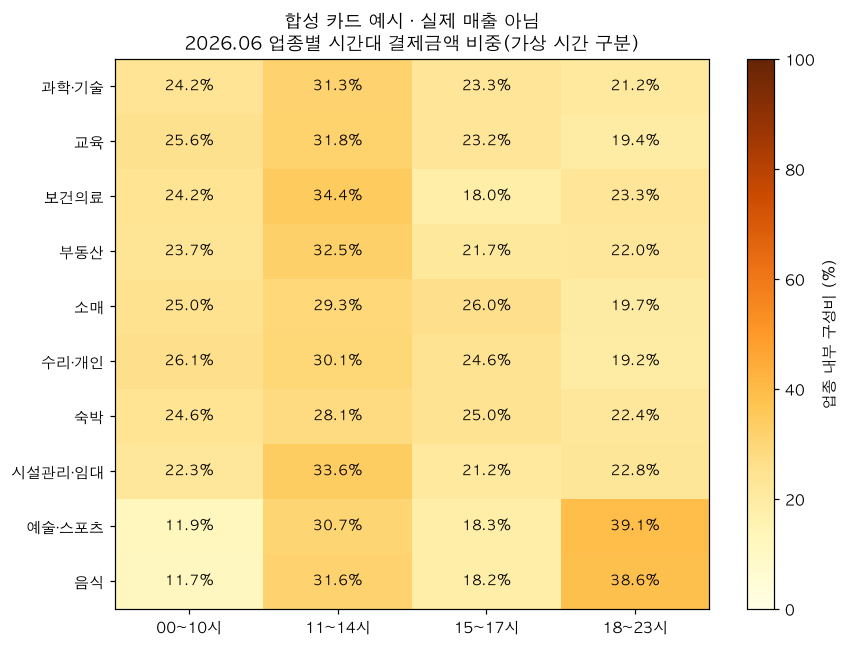

In [10]:
heat = jun.pivot_table(index='indsLclsNm',columns='TIZO_CLCD',values='PAYM_AMT',aggfunc='sum',fill_value=0).reindex(columns=list(time_codes))
heat = heat.div(heat.sum(axis=1),axis=0)*100
assert np.allclose(heat.sum(axis=1),100)
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(heat.to_numpy(),cmap='YlOrBr',vmin=0,vmax=100,aspect='auto')
ax.set(xticks=np.arange(4),xticklabels=list(time_codes.values()),yticks=np.arange(len(heat)),yticklabels=heat.index,
       title=TITLE+'\n2026.06 업종별 시간대 결제금액 비중(가상 시간 구분)')
for i in range(len(heat)):
    for j in range(4):
        ax.text(j,i,f'{heat.iloc[i,j]:.1f}%',ha='center',va='center',fontsize=9)
fig.colorbar(im,ax=ax,label='업종 내부 구성비 (%)')
chart_done(fig,'SYNTHETIC_industry_time_heatmap.png')
export_demo(heat.reset_index(),'SYNTHETIC_industry_time_shares.csv')


## 9. 실제 주민 연령구조와 합성 거래 연령구조

동일한 **2026.06·행정동 전체·20~79세** 범위로 맞춥니다. 주민은 인원, 카드는 결제건수입니다.
거래를 많이 한 사람은 더 많이 반영되므로 두 구성비의 차이를 학생 비중·외부 방문객 비중으로 해석하지 않습니다.


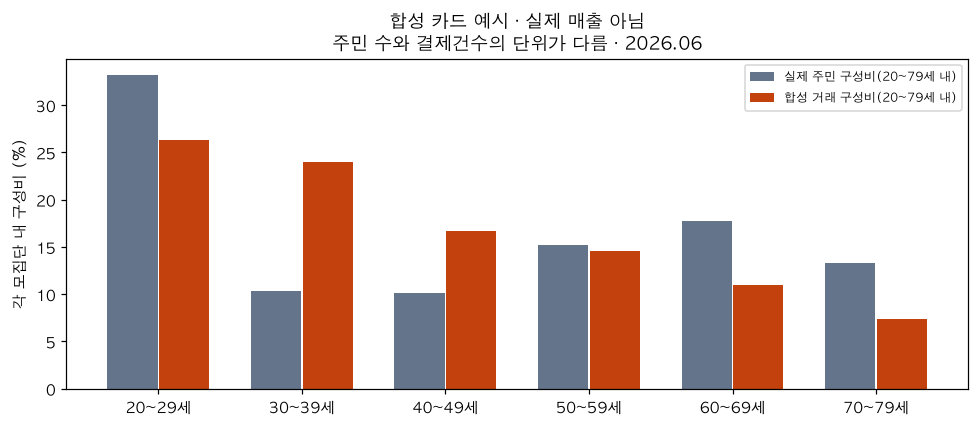

In [11]:
age_real = pd.read_csv(ROOT/'outputs/population_age_1year.csv',dtype={'month':str,'dong_code':str})
age_real = age_real[age_real.month.eq('202606')&age_real.dong_code.eq(TARGET_DONG)&age_real.sex.eq('계')&age_real.age_lower.between(20,79)].copy()
age_real['N10_UNIT_AGE_CLCD'] = 'D'+(age_real.age_lower//10).astype(str)
resident = age_real.groupby('N10_UNIT_AGE_CLCD').population.sum()
transactions = jun.groupby('N10_UNIT_AGE_CLCD').PAYM_NOCA.sum()
ages = pd.DataFrame({'real_residents_20_79':resident,'synthetic_transactions_20_79':transactions}).reindex(age_codes)
assert ages.notna().all().all()
ages['real_resident_share_pct'] = ages.real_residents_20_79/ages.real_residents_20_79.sum()*100
ages['synthetic_transaction_share_pct'] = ages.synthetic_transactions_20_79/ages.synthetic_transactions_20_79.sum()*100
ages['age_label'] = ages.index.map(age_codes)
export_demo(ages.reset_index(),'SYNTHETIC_card_REAL_resident_age_202606.csv')
fig, ax = plt.subplots(figsize=(9,4))
xx = np.arange(len(ages))
ax.bar(xx-.18,ages.real_resident_share_pct,width=.35,label='실제 주민 구성비(20~79세 내)',color='#64748b')
ax.bar(xx+.18,ages.synthetic_transaction_share_pct,width=.35,label='합성 거래 구성비(20~79세 내)',color='#c2410c')
ax.set(xticks=xx,xticklabels=ages.age_label,ylabel='각 모집단 내 구성비 (%)',title=TITLE+'\n주민 수와 결제건수의 단위가 다름 · 2026.06')
ax.legend(fontsize=8)
chart_done(fig,'SYNTHETIC_card_REAL_resident_age.png')


## 10. 인구·버스는 실제 확보 시점에만 연결

6월 자료를 2024~2026년 모든 달에 복사하지 않습니다. 8월 인구는 카드 예제 기간 밖이라 이번 결합에 사용하지 않습니다.
버스는 기존 위치 매칭 자료에서 **사용자 경계 내부 또는 경계로부터 근사 100m 이내 정류장**을 고릅니다.
이는 편의를 위한 인접 범위이며 실제 보행 접근권이 아닙니다. 정류장 승하차와 동 카드매출의 공간·모집단도 다릅니다.
**버스 이용건수로 카드 건수를 나눈 소비전환율은 계산하지 않습니다.**


In [12]:
from analyze_inha_boundary import contains, edge_distance
bus = pd.read_csv(ROOT/'outputs/bus_matched.csv',dtype={'stop_id':str})
origin = ring[:-1].mean(axis=0)
scale = np.array([np.cos(np.radians(origin[1])),1])*np.pi/180*6371000
local_ring = ((ring-origin)*scale).tolist()
local_bus = (bus[['lon','lat']].to_numpy()-origin)*scale
near = np.array([contains(p,local_ring) or edge_distance(p,local_ring)<=100 for p in local_bus])
bus_near = bus.loc[near,['stop_id','정류장명','lat','lon','daily_passengers']].copy()
assert not bus_near.duplicated(['stop_id','정류장명']).any()
bus_near.assign(data_status='REAL — 2026.06 승하차 / 위치는 2025.10').to_csv(OUT/'REAL_near_boundary_bus_stops.csv',index=False,encoding='utf-8-sig')
pop_target = population[population.dong_code.eq(TARGET_DONG)].rename(columns={'month':'STD_YM','dong_code':'UMD_CD'})
context_monthly = monthly.merge(pop_target[['STD_YM','UMD_CD','total_population','age_20_39_pct','age_65_plus_pct']],on=['STD_YM','UMD_CD'],how='left',validate='many_to_one')
context_monthly['real_near_boundary_bus_board_alight_daily'] = np.nan
is_june_target = context_monthly.STD_YM.eq('202606')&context_monthly.UMD_CD.eq(TARGET_DONG)
context_monthly.loc[is_june_target,'real_near_boundary_bus_board_alight_daily'] = bus_near.daily_passengers.sum()
assert context_monthly.total_population.notna().sum() == 1
assert context_monthly.real_near_boundary_bus_board_alight_daily.notna().sum() == 1
assert context_monthly.PAYM_AMT.sum() == card.PAYM_AMT.sum()
export_demo(context_monthly,'SYNTHETIC_card_REAL_calendar_population_bus.csv')
display(context_monthly[is_june_target][['region_label','STD_YM','PAYM_AMT','total_population','age_20_39_pct','real_near_boundary_bus_board_alight_daily']].assign(card_status='SYNTHETIC'))
display(bus_near)
print('다른 달의 실제 인구·버스 배경은 결측 유지: 값을 만들어 채우지 않음')


,region_label,STD_YM,PAYM_AMT,total_population,age_20_39_pct,real_near_boundary_bus_board_alight_daily,card_status
29,용현1.4동 가상값,202606,1570038943,"17,361.000",37.026,"6,706.810",SYNTHETIC


,stop_id,정류장명,lat,lon,daily_passengers
5013,37165,인하대후문,37.451,126.656,"1,843.870"
5014,37166,인하대후문,37.451,126.657,333.800
5015,37167,인하대후문,37.451,126.656,"2,234.500"
5257,37168,정석항공과학고,37.450,126.660,973.870
5258,37170,정석항공과학고,37.450,126.660,"1,320.770"


다른 달의 실제 인구·버스 배경은 결측 유지: 값을 만들어 채우지 않음


## 11. ‘문제 후보’ 표 작성 예시

아래 표는 생성식에 넣은 패턴이 어떤 집계로 보이는지 확인하는 절차입니다. 합성 음식 거래에 15% 감소를 넣었지만,
학사일정·월별 변동 등이 함께 있어 집계 비율이 정확히 -15%가 될 필요는 없습니다.
**실제 상권의 쇠퇴·사업 효과·원인 판정은 전부 보류합니다.**


In [13]:
# 음식 거래의 2026년 상반기/2025년 상반기 비교: 동일 6개월만 사용.
screen = food_month[food_month.STD_YM.isin([f'{y}{m:02d}' for y in [2025,2026] for m in range(1,7)])].copy()
screen['year'] = screen.STD_YM.str[:4]
half = screen.groupby(['UMD_CD','year'])[['PAYM_NOCA','calendar_days']].sum()
half['count_per_calendar_day'] = half.PAYM_NOCA/half.calendar_days
change = half.count_per_calendar_day.unstack('year')
change['synthetic_change_pct'] = (change['2026']/change['2025']-1)*100
change['label'] = change.index.map({TARGET_DONG:TARGET_NAME+' 가상값',REFERENCE_DONG:'완전 가상 비교지역'})
display(change.reset_index().assign(data_status='SYNTHETIC'))
diagnostic = pd.DataFrame([
    ['음식 거래 변화','합성 시계열로 계산됨','실제 카드 시계열·포착률·동일계절 비교','실제 문제 판단 불가'],
    ['학기 관련 패턴','생성식에 학기 효과를 넣음','실제 카드·학사일정·현장 근거','실제 원인 판단 불가'],
    ['업종 구성 차이','실제 점포와 합성 소비를 결합','공식 업종 대응·실제 소비·운영 규모','과밀/공급부족 판단 불가'],
    ['폐업·공실','현재 자료 없음','인허가 이력·반복 현장 확인','판단 유보'],
    ['보행·이용 불편','정류장 배경만 있음','실제 동선 관찰·이용자 의견','판단 유보'],
],columns=['문제 후보','이 예제에서 확인한 것','실제 진단에 필요한 근거','판단'])
display(diagnostic)
export_demo(change.reset_index(),'SYNTHETIC_food_screening.csv')
diagnostic.to_csv(OUT/'demo_diagnostic_limits.csv',index=False,encoding='utf-8-sig')


year,UMD_CD,2025,2026,synthetic_change_pct,label,data_status
0,2817754000,"2,123.884","1,851.867",-12.808,용현1.4동 가상값,SYNTHETIC
1,DEMO000001,"1,602.934","1,656.425",3.337,완전 가상 비교지역,SYNTHETIC


,문제 후보,이 예제에서 확인한 것,실제 진단에 필요한 근거,판단
0,음식 거래 변화,합성 시계열로 계산됨,실제 카드 시계열·포착률·동일계절 비교,실제 문제 판단 불가
1,학기 관련 패턴,생성식에 학기 효과를 넣음,실제 카드·학사일정·현장 근거,실제 원인 판단 불가
2,업종 구성 차이,실제 점포와 합성 소비를 결합,공식 업종 대응·실제 소비·운영 규모,과밀/공급부족 판단 불가
3,폐업·공실,현재 자료 없음,인허가 이력·반복 현장 확인,판단 유보
4,보행·이용 불편,정류장 배경만 있음,실제 동선 관찰·이용자 의견,판단 유보


## 12. 실제 카드자료로 교체하기 전 확인

1. `UMD_CD`가 행정동인지 법정동인지, 코드 길이·기준연도를 확인합니다.
2. 가상 `D...` 코드표를 폐기하고 공식 업종·연령·시간·공휴일·유입 코드표로 교체합니다.
3. 금액 단위, 실매출/추정매출, 개인·법인, 취소·음수·마스킹·소수집계, 합계행 유무를 확인합니다.
4. 합계행과 세부행을 함께 더하지 않도록 집계 수준·고유키를 확정합니다. 실제 음수를 무조건 지우면 안 됩니다.
5. 실제 지역 중 적절한 비교지역을 선정합니다. 가상 비교지역으로 정책 효과를 추정하지 않습니다.
6. 실데이터 결과는 별도 노트북·출력 폴더에서 작성해 합성 파일과 섞이지 않게 합니다.

이 예제에서의 미공급(인구 과거 월·버스 과거 월·실제 공실·폐업)과
합성 생성 시 의도적으로 생략한 항목(실제 생애주기·소득 분포 등)을 구분합니다.

**노트북에서 하지 않는 계산:** 후문 매출 추정, 점포당 카드매출, 버스 대비 소비전환율, 실제 고객 수,
요일별 매출, 과밀·공백 판정, 인과적 사업 효과.


In [14]:
source_paths = ['data/inha_boundary.geojson','data/raw/district_stores.json','outputs/inha/stores.csv',
    'outputs/population_dong_summary.csv','outputs/population_age_1year.csv','outputs/bus_matched.csv',
    'outputs/inha/academic_monthly_features.csv']
manifest = dict(data_status=CARD_STATUS,seed=SEED,synthetic_rows=len(card),fields=fields,
    period=['202401','202606'],target_dong_assumption=TARGET_DONG,comparison_region=REFERENCE_DONG,
    official_codebook_verified=False,amount_unit='KRW assumed for demo only',
    generator_assumptions=['실제 동 업종별 점포 수를 생성 기준 크기로 사용','가상 대상지역 청년 음식/오락에 정규학기 비중 효과',
        '202509부터 대상지역 음식 기대건수 ×0.85','비교지역 규모 ×0.85','월 성장 0.2%, 계절 진폭 4%',
        '20~79세·개인카드만 생성, 생애주기/소득 미설정, PHOLI는 가상유형'],
    versions={'numpy':np.__version__,'pandas':pd.__version__},
    sources={p:hashlib.sha256((ROOT/p).read_bytes()).hexdigest() for p in source_paths},
    synthetic_csv_sha256=hashlib.sha256((OUT/'SYNTHETIC_shc_17_fields.csv').read_bytes()).hexdigest())
(OUT/'SYNTHETIC_manifest.json').write_text(json.dumps(manifest,ensure_ascii=False,indent=2))
(OUT/'README.md').write_text('# 합성 카드 분석 예제\n\n모든 카드 결제값은 합성입니다. 실제 상권 진단·정책 근거로 사용할 수 없습니다.\n\n'
    '원본 구조 예제: SYNTHETIC_shc_17_fields.csv (17개 필드; 상태는 파일명·manifest로 표시).\n'
    '분석표는 card_data_status 열을 포함합니다. REAL_ 파일은 출처 시점이 있는 실제 배경자료입니다.\n'
    '코드표 D 값은 가상이며 공식 카드 코드가 아닙니다. 업종 매핑도 예제 가정입니다.\n'
    '실행 노트북: ../../inha_synthetic_card_demo.ipynb\n')
assert len(monthly) == len(months)*2
assert len(card) == len(months)*2*len(industry_map)*len(age_codes)*len(time_codes)*2*2*len(origin_codes)
assert len(context_monthly) == len(monthly)
print('PASS: 17개 필드·고유키·코드 길이·비음수·무거래 금액0·조인 합계·시점·업종/연령 구성비 검증')
print('합성 카드:',len(card),'행 | 월별 지역 집계:',len(monthly),'행')
print('실제 현황:',len(boundary_stores),'개 후문 점포 /',len(dong_stores),'개 동 전체 점포')
print('결과 폴더:',OUT)


PASS: 17개 필드·고유키·코드 길이·비음수·무거래 금액0·조인 합계·시점·업종/연령 구성비 검증
합성 카드: 172800 행 | 월별 지역 집계: 60 행
실제 현황: 534 개 후문 점포 / 1349 개 동 전체 점포
결과 폴더: /Users/USER/vscode/Incheon-Public-Data-Analysis/Commercial district analysis/outputs/synthetic_card_demo
